Importamos las Librerias

In [35]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Cargamos los datos

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/AlexisG81/Parcial04-AlexisGuevara2516232022/refs/heads/main/documentos/clave_F_asociacion.csv')

Mostrar las primeras filas del dataset y explicar su estructura

In [4]:
print(df.shape)

(605, 7)


In [5]:
print(df.head())


  transaccion_id cliente_id       fecha categoria      item  cantidad   canal
0        F-T0001    F-C0058  2026-01-02      Ropa  Camiseta         4  Tienda
1        F-T0001    F-C0058  2026-01-02  Ciclismo     Casco         1  Tienda
2        F-T0001    F-C0058  2026-01-02    Futbol   Chaleco         1  Tienda
3        F-T0001    F-C0058  2026-01-02  Ciclismo     Luces         1  Tienda
4        F-T0002    F-C0005  2026-01-09  Ciclismo     Casco         1     App


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  605 non-null    object
 1   cliente_id      605 non-null    object
 2   fecha           605 non-null    object
 3   categoria       605 non-null    object
 4   item            605 non-null    object
 5   cantidad        605 non-null    int64 
 6   canal           604 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.2+ KB
None


In [7]:
print(df.isnull().sum())

transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64


In [8]:
print(df.duplicated().sum())

1


In [9]:
print(df.describe())

         cantidad
count  605.000000
mean     1.403306
std      0.743174
min      1.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      4.000000


In [10]:
!pip install mlxtend

In [11]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Convertir TODOS los valores a texto

df = df.astype(str)

# Convertir a lista de transacciones

transacciones = df.values.tolist()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [14]:
te = TransactionEncoder()

te_array = te.fit(transacciones).transform(transacciones)

df_apriori = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print(df_apriori.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

       1      2  2026-01-01  2026-01-02  2026-01-03  2026-01-04  2026-01-05  \
0  False  False       False        True       False       False       False   
1   True  False       False        True       False       False       False   
2   True  False       False        True       False       False       False   
3   True  False       False        True       False       False       False   
4   True  False       False       False       False       False       False   

   2026-01-06  2026-01-07  2026-01-08  ...  Proteina   Ropa  Short  \
0       False       False       False  ...     False   True  False   
1       False       False       False  ...     False  False  False   
2       False       False       False  ...     False  False  False   
3       False       False       False  ...     False  False  False   
4       False       False       False  ...     False  False  False   

   Suplementos  Telefono  Tenis  Termo  Tienda    Web    nan  
0        False     False  False  False   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [15]:
df_apriori.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,1,2,2026-01-01,2026-01-02,2026-01-03,2026-01-04,2026-01-05,2026-01-06,2026-01-07,2026-01-08,...,Proteina,Ropa,Short,Suplementos,Telefono,Tenis,Termo,Tienda,Web,nan
0,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
1,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:


frequent_itemsets = apriori(
    df_apriori,
    min_support=0.05,
    use_colnames=True
)

print(frequent_itemsets.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    support itemsets
0  0.723967      (1)
1  0.176860      (2)
2  0.071074      (3)
3  0.254545    (App)
4  0.071074  (Balon)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
reglas = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

print(reglas.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  antecedents consequents  antecedent support  consequent support   support  \
0       (App)         (1)            0.254545            0.723967  0.185124   
1  (Calcetas)         (1)            0.079339            0.723967  0.062810   
2     (Casco)         (1)            0.071074            0.723967  0.051240   
3  (Ciclismo)         (1)            0.218182            0.723967  0.160331   
4   (Fitness)         (1)            0.216529            0.723967  0.150413   

   confidence      lift  representativity  leverage  conviction  \
0    0.727273  1.004566               1.0  0.000841    1.012121   
1    0.791667  1.093512               1.0  0.005371    1.324959   
2    0.720930  0.995805               1.0 -0.000216    0.989118   
3    0.734848  1.015030               1.0  0.002374    1.041039   
4    0.694656  0.959514               1.0 -0.006347    0.904008   

   zhangs_metric   jaccard  certainty  kulczynski  
0       0.006098  0.233333   0.011976    0.491490  
1       0.092885  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
top_reglas = reglas.sort_values(
    by='lift',
    ascending=False
)

top10 = top_reglas.head(10)

top10

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
31,(Luces),"(1, Ciclismo)",0.080992,0.160331,0.064463,0.795918,4.964233,1.0,0.051477,4.114380,0.868936,0.364486,0.756950,0.598990
13,(Balon),(Futbol),0.071074,0.203306,0.071074,1.000000,4.918699,1.0,0.056625,inf,0.857651,0.349593,1.000000,0.674797
19,(Conos),(Futbol),0.066116,0.203306,0.066116,1.000000,4.918699,1.0,0.052674,inf,0.853097,0.325203,1.000000,0.662602
25,(Calcetas),"(1, Ropa)",0.079339,0.166942,0.062810,0.791667,4.742162,1.0,0.049565,3.998678,0.857129,0.342342,0.749917,0.583952
21,(Tenis),(Ropa),0.084298,0.216529,0.084298,1.000000,4.618321,1.0,0.066045,inf,0.855596,0.389313,1.000000,0.694656
14,(Banda_elastica),(Fitness),0.079339,0.216529,0.079339,1.000000,4.618321,1.0,0.062160,inf,0.850987,0.366412,1.000000,0.683206
15,(Calcetas),(Ropa),0.079339,0.216529,0.079339,1.000000,4.618321,1.0,0.062160,inf,0.850987,0.366412,1.000000,0.683206
23,"(Calcetas, 1)",(Ropa),0.062810,0.216529,0.062810,1.000000,4.618321,1.0,0.049210,inf,0.835979,0.290076,1.000000,0.645038
20,(Mat),(Fitness),0.067769,0.216529,0.067769,1.000000,4.618321,1.0,0.053095,inf,0.840426,0.312977,1.000000,0.656489
36,"(1, Tenis)",(Ropa),0.059504,0.216529,0.059504,1.000000,4.618321,1.0,0.046620,inf,0.833040,0.274809,1.000000,0.637405


In [22]:
top10[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]]

,antecedents,consequents,support,confidence,lift
31,(Luces),"(1, Ciclismo)",0.064463,0.795918,4.964233
13,(Balon),(Futbol),0.071074,1.000000,4.918699
19,(Conos),(Futbol),0.066116,1.000000,4.918699
25,(Calcetas),"(1, Ropa)",0.062810,0.791667,4.742162
21,(Tenis),(Ropa),0.084298,1.000000,4.618321
14,(Banda_elastica),(Fitness),0.079339,1.000000,4.618321
15,(Calcetas),(Ropa),0.079339,1.000000,4.618321
23,"(Calcetas, 1)",(Ropa),0.062810,1.000000,4.618321
20,(Mat),(Fitness),0.067769,1.000000,4.618321
36,"(1, Tenis)",(Ropa),0.059504,1.000000,4.618321


#CARGAMOS LOS DATOS DEL SIGUIENTE

CORRELACIÓN

In [26]:
df_corr = pd.read_csv('https://raw.githubusercontent.com/AlexisG81/Parcial04-AlexisGuevara2516232022/refs/heads/main/documentos/clave_F_correlacion.csv')

Revisamos la informacion

In [27]:
print(df_corr.shape)

(246, 10)


In [28]:
df_corr.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,F-C0001,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,F-C0002,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,F-C0003,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,F-C0004,48,783,4,37.37,5.69,4,4,26.98,233.89
4,F-C0005,31,1187,7,65.26,3.50,8,7,28.48,386.42


In [29]:
print(df_corr.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          246 non-null    object 
 1   edad                246 non-null    int64  
 2   ingresos_mensuales  246 non-null    int64  
 3   frecuencia_compra   246 non-null    int64  
 4   ticket_promedio     245 non-null    float64
 5   satisfaccion        245 non-null    float64
 6   reclamos            246 non-null    int64  
 7   uso_app             246 non-null    int64  
 8   tiempo_respuesta    245 non-null    float64
 9   consumo_total       246 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 19.3+ KB
None


In [30]:
print(df_corr.isnull().sum())

cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


In [31]:
print(df_corr.duplicated().sum())

1


In [32]:
print(df.describe())

       transaccion_id cliente_id       fecha categoria   item cantidad   canal
count             605        605         605       605    605      605     605
unique            190         87          99         5     20        4       5
top           F-T0005    F-C0071  2026-01-18  Ciclismo  Tenis        1  Tienda
freq                6         24          16       132     51      438     290


In [36]:
variables_numericas = df_corr.select_dtypes(include=np.number)

variables_numericas.head()

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,48,783,4,37.37,5.69,4,4,26.98,233.89
4,31,1187,7,65.26,3.50,8,7,28.48,386.42


MATRIZ DE CORRELACIÓN

In [37]:
correlacion = variables_numericas.corr()

correlacion

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.069731,0.074371,0.139288,-0.015866,0.046094,0.061604,0.018706,0.096946
ingresos_mensuales,0.069731,1.000000,0.066022,0.664902,-0.059353,0.006382,-0.044790,0.164896,0.322528
frecuencia_compra,0.074371,0.066022,1.000000,0.168946,0.127013,-0.069325,0.401293,-0.081970,0.896130
ticket_promedio,0.139288,0.664902,0.168946,1.000000,-0.031010,-0.008410,-0.005957,0.068131,0.526827
satisfaccion,-0.015866,-0.059353,0.127013,-0.031010,1.000000,-0.829036,0.245222,-0.620456,0.180135
reclamos,0.046094,0.006382,-0.069325,-0.008410,-0.829036,1.000000,-0.021190,0.616314,-0.140812
uso_app,0.061604,-0.044790,0.401293,-0.005957,0.245222,-0.021190,1.000000,-0.208868,0.392901
tiempo_respuesta,0.018706,0.164896,-0.081970,0.068131,-0.620456,0.616314,-0.208868,1.000000,-0.117412
consumo_total,0.096946,0.322528,0.896130,0.526827,0.180135,-0.140812,0.392901,-0.117412,1.000000


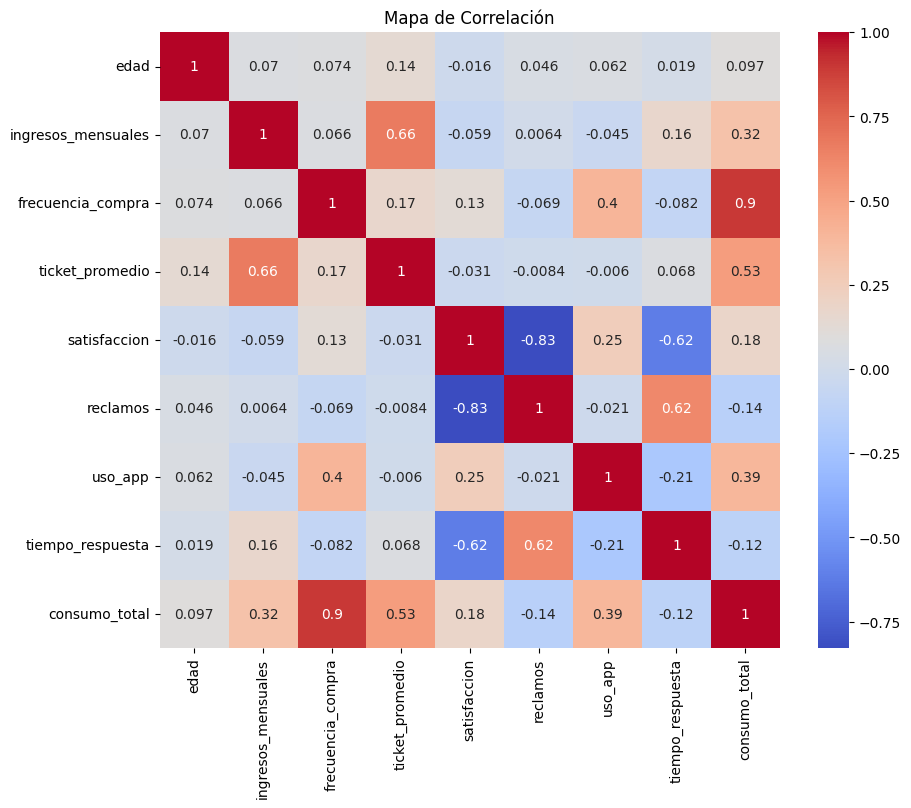

In [38]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm'
)

plt.title("Mapa de Correlación")

plt.show()

In [39]:
correlacion.unstack().sort_values(
    ascending=False
)

edad                edad                  1.000000
ingresos_mensuales  ingresos_mensuales    1.000000
uso_app             uso_app               1.000000
consumo_total       consumo_total         1.000000
tiempo_respuesta    tiempo_respuesta      1.000000
                                            ...   
uso_app             tiempo_respuesta     -0.208868
tiempo_respuesta    satisfaccion         -0.620456
satisfaccion        tiempo_respuesta     -0.620456
                    reclamos             -0.829036
reclamos            satisfaccion         -0.829036
Length: 81, dtype: float64

In [40]:
correlacion.unstack().sort_values()

reclamos            satisfaccion         -0.829036
satisfaccion        reclamos             -0.829036
                    tiempo_respuesta     -0.620456
tiempo_respuesta    satisfaccion         -0.620456
                    uso_app              -0.208868
                                            ...   
ingresos_mensuales  ingresos_mensuales    1.000000
edad                edad                  1.000000
frecuencia_compra   frecuencia_compra     1.000000
tiempo_respuesta    tiempo_respuesta      1.000000
consumo_total       consumo_total         1.000000
Length: 81, dtype: float64

# AGRUPACION

In [51]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/AlexisG81/Parcial04-AlexisGuevara2516232022/refs/heads/main/documentos/clave_F_agrupacion.csv'
)

# REVISAR INFORMACIÓN

In [52]:
print(df.shape)

df.head()

(250, 8)


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,F-R0218,47,1028,5.48,63.75,3.04,5,13
1,F-R0008,35,733,1.41,25.26,5.60,3,3
2,F-R0082,36,985,9.98,98.95,7.11,3,27
3,F-R0009,30,473,1.61,5.00,5.76,12,1
4,F-R0244,39,978,2.57,27.35,3.31,4,10


In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       250 non-null    object 
 1   edad              250 non-null    int64  
 2   ingresos          250 non-null    int64  
 3   frecuencia_uso    250 non-null    float64
 4   gasto_promedio    250 non-null    float64
 5   satisfaccion      249 non-null    float64
 6   reclamos          250 non-null    int64  
 7   antiguedad_meses  250 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 15.8+ KB
None


In [54]:
print(df.isnull().sum())

registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64


In [55]:
print(df.duplicated().sum())

0


## Revisión del dataset

Se verificaron:
- tipos de datos
- valores nulos
- registros duplicados

para asegurar la calidad de la información antes de aplicar clustering.

In [56]:
X = df.select_dtypes(include=np.number)

X.head()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,47,1028,5.48,63.75,3.04,5,13
1,35,733,1.41,25.26,5.60,3,3
2,36,985,9.98,98.95,7.11,3,27
3,30,473,1.61,5.00,5.76,12,1
4,39,978,2.57,27.35,3.31,4,10


Se seleccionaron variables numéricas porque permiten medir similitudes entre clientes y aplicar correctamente algoritmos de agrupación.

# ESCALAR DATOS

In [59]:
# Eliminar valores nulos

X = X.dropna()

In [57]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Los datos fueron normalizados utilizando StandardScaler para evitar que variables con valores más grandes tengan mayor influencia en el análisis.

In [61]:
X = df.select_dtypes(include=np.number)

X.head()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,47,1028,5.48,63.75,3.04,5,13
1,35,733,1.41,25.26,5.60,3,3
2,36,985,9.98,98.95,7.11,3,27
3,30,473,1.61,5.00,5.76,12,1
4,39,978,2.57,27.35,3.31,4,10


In [62]:
# Eliminar valores nulos

X = X.dropna()

In [63]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [65]:
inertia = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

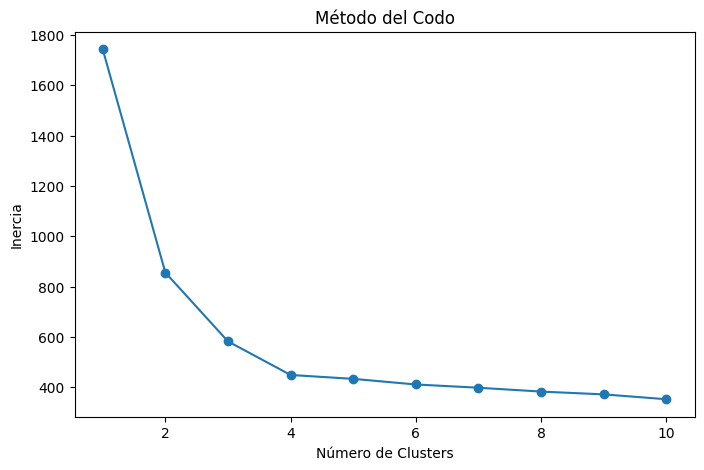

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Método del Codo")

plt.xlabel("Número de Clusters")

plt.ylabel("Inercia")

plt.show()

## Método del codo

El método del codo permite identificar el número óptimo de grupos observando el punto donde la disminución de la inercia comienza a estabilizarse.

In [67]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [68]:
# Mantener mismas filas

df = df.loc[X.index]

# Agregar clusters

df['Cluster'] = clusters

df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,Cluster
0,F-R0218,47,1028,5.48,63.75,3.04,5,13,0
1,F-R0008,35,733,1.41,25.26,5.60,3,3,0
2,F-R0082,36,985,9.98,98.95,7.11,3,27,2
3,F-R0009,30,473,1.61,5.00,5.76,12,1,0
4,F-R0244,39,978,2.57,27.35,3.31,4,10,0


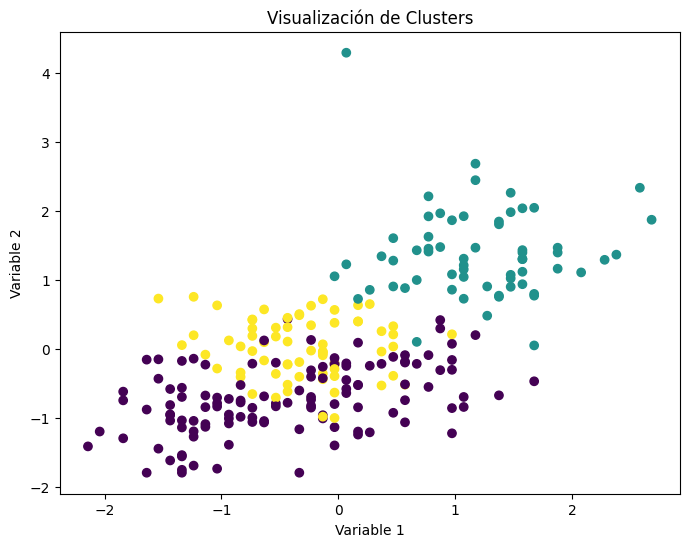

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters
)

plt.title("Visualización de Clusters")

plt.xlabel("Variable 1")

plt.ylabel("Variable 2")

plt.show()